# Objectif :
## Comprendre le dataset de maintenance prédictive

In [7]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/processed/preprocessed_data.csv")
df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,2015-01-01,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [8]:
df.info()
df.shape



<class 'pandas.DataFrame'>
RangeIndex: 124493 entries, 0 to 124492
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   date     124493 non-null  str  
 1   device   124493 non-null  str  
 2   failure  124493 non-null  int64
 3   metric1  124493 non-null  int64
 4   metric2  124493 non-null  int64
 5   metric3  124493 non-null  int64
 6   metric4  124493 non-null  int64
 7   metric5  124493 non-null  int64
 8   metric6  124493 non-null  int64
 9   metric7  124493 non-null  int64
 10  metric8  124493 non-null  int64
 11  metric9  124493 non-null  int64
dtypes: int64(10), str(2)
memory usage: 11.4 MB


(124493, 12)

 *vérifié la structure des données avec df.info(). Le dataset contient environ 124 000 observations, sans valeurs manquantes, et j’ai supprimé un doublon. Les données sont principalement numériques, ce qui facilite la modélisation*


In [9]:
df["failure"].value_counts()
df["failure"].value_counts(normalize=True)


failure
0    0.999149
1    0.000851
Name: proportion, dtype: float64

*Le dataset est très déséquilibré, avec environ 99 de données normales et très peu de pannes. Cela signifie que l’accuracy n’est pas une métrique fiable, et qu’il faut privilégier des métriques comme le recall pour détecter les pannes*

In [10]:
df.describe()

,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
count,124493.000000,1.244930e+05,124493.000000,124493.000000,124493.000000,124493.000000,124493.000000,124493.000000,124493.000000,124493.000000
mean,0.000851,1.223875e+08,159.493988,9.940977,1.741134,14.222719,260173.031022,0.292531,0.292531,13.013953
std,0.029167,7.045934e+07,2179.686488,185.748875,22.908598,15.943082,99151.389285,7.436954,7.436954,275.662324
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000
25%,0.000000,6.128346e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000
50%,0.000000,1.227971e+08,0.000000,0.000000,0.000000,10.000000,249800.000000,0.000000,0.000000,0.000000
75%,0.000000,1.833091e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000
max,1.000000,2.441405e+08,64968.000000,24929.000000,1666.000000,98.000000,689161.000000,832.000000,832.000000,70000.000000


In [11]:
metrics = [
    "metric1", "metric2", "metric3", "metric4", "metric5",
    "metric6", "metric7", "metric8", "metric9"
]

df.groupby("failure")[metrics].mean()  


,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
failure,,,,,,,,,
0,1.223835e+08,156.127931,9.94612,1.696061,14.221663,260174.624213,0.266684,0.266684,13.005370
1,1.271755e+08,4109.433962,3.90566,54.632075,15.462264,258303.481132,30.622642,30.622642,23.084906


*J’ai utilisé groupby pour séparer les machines normales et en panne, puis j’ai calculé la moyenne des métriques afin d’identifier celles qui changent le plus et peuvent être utilisées pour prédire les pannes*  
*J’ai comparé les métriques entre les machines normales et en panne. Certaines variables comme metric2, metric4, metric7 et metric8 présentent des différences très importantes, ce qui suggère qu’elles sont fortement liées aux pannes et seront utiles pour la prédiction *

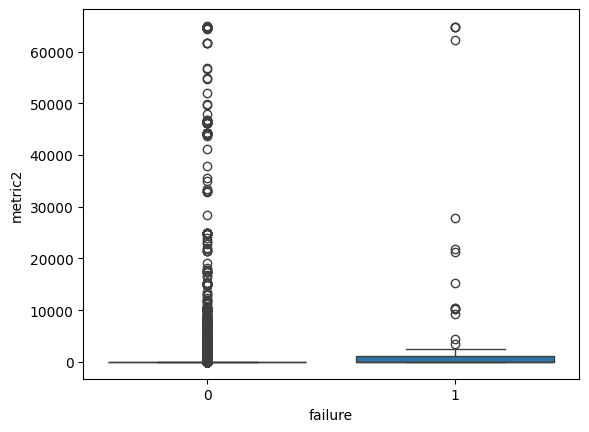

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="failure", y="metric2", data=df)
plt.show()

## Les boxplots m’ont permis de comparer les métriques entre les machines normales et en panne, et d’identifier les variables les plus discriminantes.

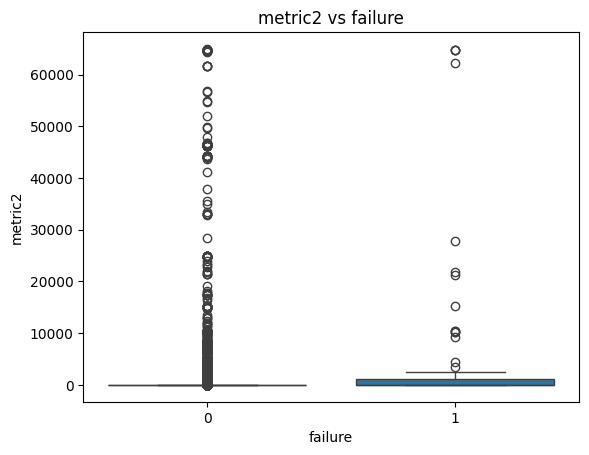

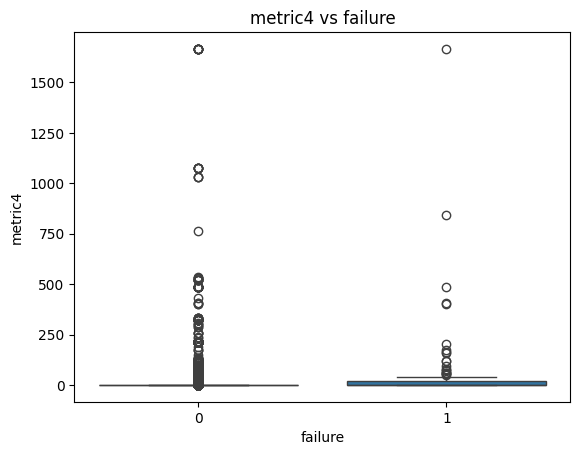

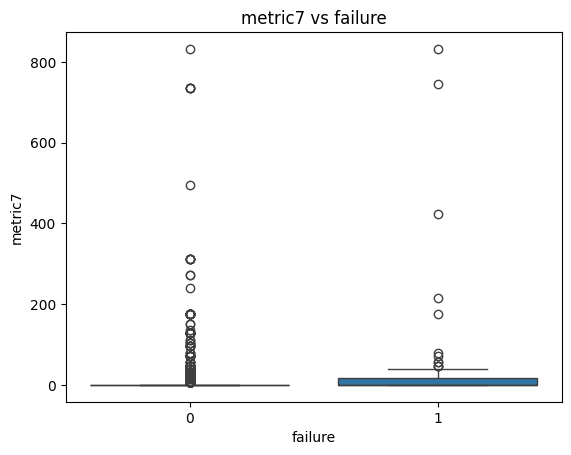

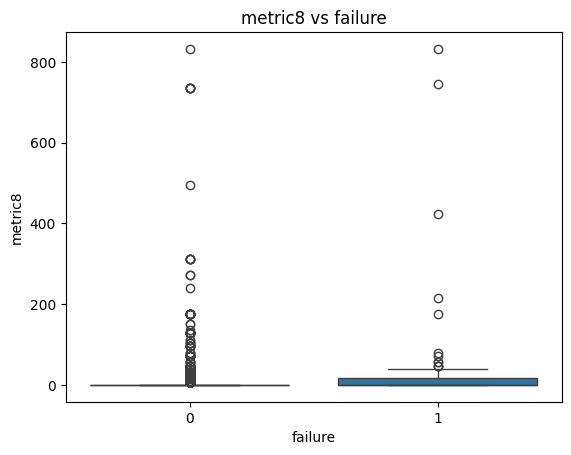

In [13]:
metrics = ["metric2", "metric4", "metric7", "metric8"]

for m in metrics:
    sns.boxplot(x="failure", y=m, data=df)
    plt.title(f"{m} vs failure")
    plt.show()

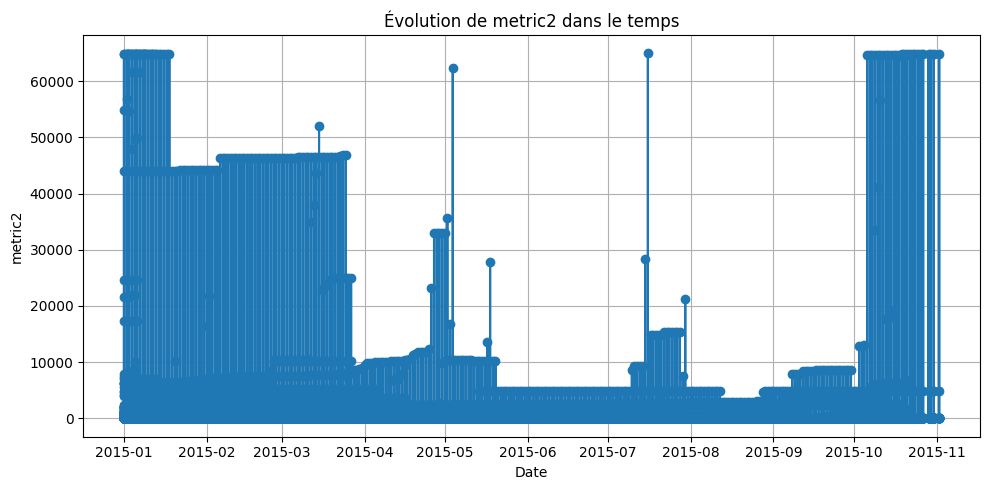

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/preprocessed_data.csv")

df["date"] = pd.to_datetime(df["date"])

df_sorted = df.sort_values("date")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["date"], df_sorted["metric2"], marker="o")

plt.title("Évolution de metric2 dans le temps")
plt.xlabel("Date")
plt.ylabel("metric2")
plt.grid(True)
plt.tight_layout()
plt.show()


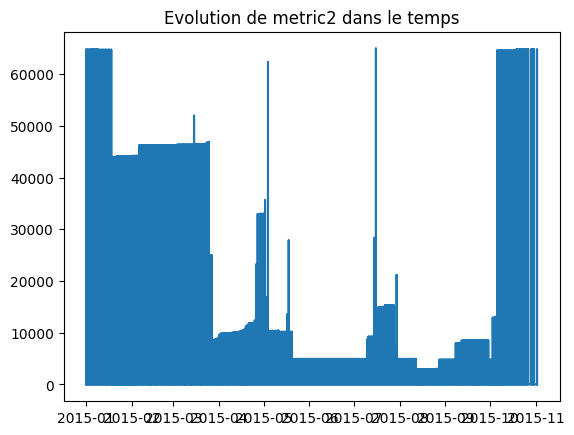

In [16]:



plt.plot(df_sorted["date"], df_sorted["metric2"])
plt.title("Evolution de metric2 dans le temps")
plt.show()